<a id="top"></a>
# Estimating Galaxy Cluster Masses with Convolutional Neural Networks

***

## Learning Goals


**In this tutorial, you will see an example of building, compiling, and training a CNN on simulated astronomical data.**  By the end of this tutorial you will have a working example of a simple Convolutional Neural Network (CNN) in Keras.  This CNN can be adapted for any machine learning task that inputs an image and learns a continuous-valued label (regression). 

## Introduction
Convolutional Neural Networks (CNNs) are a class of machine learning (ML) algorithms that can extract information from images.  In this notebook, you will walk through the basic steps of applying a CNN to data:
1. Load the data and visualize a sample of the data
2. Divide the data into training, validation, and testing sets.
3. Build a CNN in Keras
4. Compile the CNN
5. Train the CNN to perform a regression task
6. Evaluate the results.

CNNs can be applied to a wide range of image recognition tasks, and while they are often used for image classification, this notebook builds a CNN for an image regression task.  Here, we will build, compile, and train CNN to estimate galaxy cluster log(masses) from simulated single-band (or _monochromatic_) X-ray images of galaxy clusters.


## Imports
This notebook uses the following:
- *numpy* to handle array functions
- *astropy.io fits* for accessing FITS files
- *matplotlib.pyplot* for plotting data
- *keras* for building the CNN

In [1]:
import numpy as np
print(np.__version__)
print(np.__file__)

2.4.6
C:\Users\ulkar\miniconda3\envs\alita2026\Lib\site-packages\numpy\__init__.py


In [2]:
import os
import sys

print(sys.executable)
print(np.__file__)

C:\Users\ulkar\miniconda3\envs\alita2026\python.exe
C:\Users\ulkar\miniconda3\envs\alita2026\Lib\site-packages\numpy\__init__.py


In [3]:
import numpy as np
print("NumPy:", np.__version__)

import tensorflow as tf
print("TensorFlow:", tf.__version__)

import keras
print("Keras:", keras.__version__)

NumPy: 2.4.6


C:\Users\ulkar\miniconda3\envs\alita2026\Lib\site-packages\scipy\__init__.py:160: UserWarning: A NumPy version >=1.19.5 and <1.27.0 is required for this version of SciPy (detected version 2.4.6)
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"

A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "C:\Users\ulkar\miniconda3\envs\alita2026\Lib\runpy.py", line 198, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "C:\Users\ulkar\miniconda3\envs\alita2026\Lib\runpy.py", line 88, in _run_code
    exec(code, run_globals)
 

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "C:\Users\ulkar\miniconda3\envs\alita2026\Lib\runpy.py", line 198, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "C:\Users\ulkar\miniconda3\envs\alita2026\Lib\runpy.py", line 88, in _run_code
    exec(code, run_globals)
  File "C:\Users\ulkar\miniconda3\envs\alita2026\Lib\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "C:\Users\ulkar\miniconda3\envs\alita2026\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instan

AttributeError: _ARRAY_API not found

...


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "C:\Users\ulkar\miniconda3\envs\alita2026\Lib\runpy.py", line 198, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "C:\Users\ulkar\miniconda3\envs\alita2026\Lib\runpy.py", line 88, in _run_code
    exec(code, run_globals)
  File "C:\Users\ulkar\miniconda3\envs\alita2026\Lib\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "C:\Users\ulkar\miniconda3\envs\alita2026\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instan

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "C:\Users\ulkar\miniconda3\envs\alita2026\Lib\runpy.py", line 198, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "C:\Users\ulkar\miniconda3\envs\alita2026\Lib\runpy.py", line 88, in _run_code
    exec(code, run_globals)
  File "C:\Users\ulkar\miniconda3\envs\alita2026\Lib\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "C:\Users\ulkar\miniconda3\envs\alita2026\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instan

AttributeError: _ARRAY_API not found

TensorFlow: 2.21.0
Keras: 3.15.1


In [4]:
%matplotlib inline
import numpy as np
from astropy.io import fits
import matplotlib.pyplot as plt
import keras
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten
from keras.layers import Conv2D, MaxPooling2D, GlobalAveragePooling2D, BatchNormalization
from keras import backend as K

***

## CNNs for Regression

### 1. Load the data and visualize a sample of the data

Load the simulated x-ray cluster observations (input images) and cluster log masses (output labels).  These data are described in detail in [Ntampaka et al 2019](https://ui.adsabs.harvard.edu/abs/2019ApJ...876...82N/abstract).  

Briefly, they are 100ks simulated Chandra observations of galaxy clusters in the Illustris TNG simulation.  The images are for a single, large spectral band (0.5-2keV) and are labeled with the cluster masses (log(M500c) in Msolar/h).  The CNN will be used to estimate cluster masses from the simulated cluster images.

#### Load the data

In [5]:
# You will need to set this path according to where you've stored the data set on your machine!
filename = r'C:\Users\ulkar\Desktop\work2026 g-lamp\Cluster Mass Hack-20260824T084340Z-1-001\Cluster Mass Hack\cluster_TNG_data.fits'
hdul = fits.open(filename)

#### File Information

Fits is a commonly used data format for astronomical images.  Next, we'll go through some illustritive examples of working with fits files.  Familiarity with fits files is not a requirement for this tutorial, but we refer you to the [Astropy Documentation](https://docs.astropy.org/en/stable/io/fits/index.html) if you want further information about this file format.

In [6]:
# Metadata about this observation is available in the header
print(hdul[0].header)

SIMPLE  =                    T / conforms to FITS standard                      BITPIX  =                    8 / array data type                                NAXIS   =                    0 / number of array dimensions                     EXTEND  =                    T                                                  SIMULATD= 'T       '                                                            HLSPVER = '0       '                                                            HLSPID  = 'XXXX    '                                                            DOI     = 'XXXX    '                                                            INSTRUME= 'ACIS-I  '                                                            LICENSE = 'CC BY 4.0'                                                           LICENURL= 'https://creativecommons.org/licenses/by/4.0/'                        OBSERVAT= 'Chandra '                                                            XPOSURE = '100ks   '                    

C:\Users\ulkar\AppData\Local\Temp\ipykernel_27776\1284549622.py:8: RuntimeWarning: divide by zero encountered in log10
  plt.imshow(np.log10(hdul[1].data[n]), vmin=0, vmax=2.7)


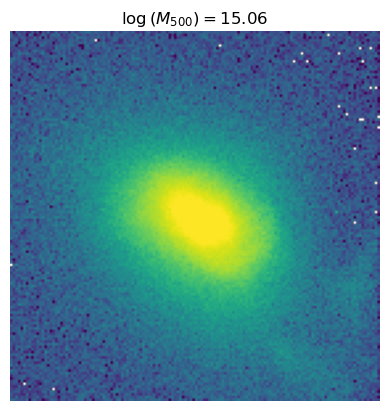

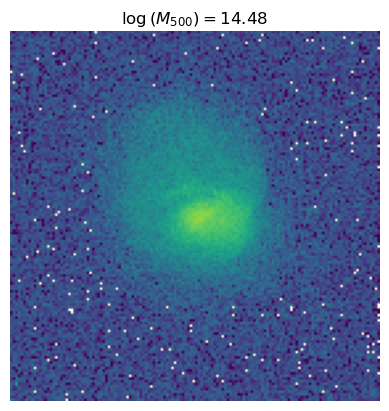

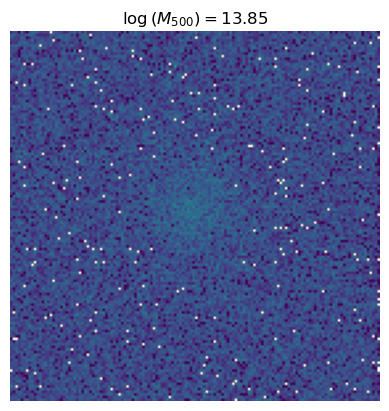

In [7]:
# We can plot a few sample images and label them with their masses

image_size = hdul[1].data.shape[1]

for n in [0, 100, 900]:
    plt.figure()
    #plot the image
    plt.imshow(np.log10(hdul[1].data[n]), vmin=0, vmax=2.7)
    plt.axis('off')
    plt.title(r'$\log\left(M_\mathrm{500}\right)=$'+'{:.2f}'.format(hdul[2].data['log_M500'][n]))

#### Comments on the sample images
As you can see above, there are some pixels with no photons (they are displayed as white squares).  It's also interesting to note that the images vary significantly in total luminosity; the figures above show the log of the number of photons, and even so, the lowest-mass cluster is barely visible and the highest-mass cluster is saturated at the core for this colormap.


### 2. Divide the data into training, validation, and testing sets.

There are a number of tools for dividing a data set into training, validation, and testing data, such as Scikit-Learn's [train_test_split](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html).  For this work, the author has divided the data into folds and has provided a recommendation for how to divide these into training, validation, and testing sets.

We will denote the input images as "X" and the output labels as "Y".

Note that we are reshaping the image array as follows:  (number_of_images, image_width, image_length, 1) 
This is referred to as a "channels last" approach, where the final axis denotes the number of "colors" or "channels".  Our monochromatic image only has a single channel, while RGB images have three.  CNN's will work with an arbitrary number of channels.



In [8]:
train_ind = np.argwhere(hdul[2].data['train'] == 1)
train_X = hdul[1].data[train_ind].reshape(-1, image_size, image_size, 1)
train_Y = hdul[2].data['log_M500'][train_ind]

val_ind = np.argwhere(hdul[2].data['validate'] == 1)
val_X = hdul[1].data[val_ind].reshape(-1, image_size, image_size, 1)
val_Y = hdul[2].data['log_M500'][val_ind]

test_ind = np.argwhere(hdul[2].data['test'] == 1)
test_X = hdul[1].data[test_ind].reshape(-1, image_size, image_size, 1)
test_Y = hdul[2].data['log_M500'][test_ind]

ML models often converge faster when the output is _roughly_ between 0 and 1. Next, let's perform a normalization that will speed up the training process a bit -- calculate the minimum log(mass) and subtract it from the Y labels as a change of units.  We'll put it back, later in the notebook, just before we plot the results.  

We can simply subtract off a constant value because our output doesn't have a large dynamical range, but there may be cases where you want to handle this more carefully and force all of your labels to be strictly in the (0,1) interval.  

In [9]:
norm = np.nanmin(hdul[2].data['log_M500'])
train_Y -= norm
val_Y -= norm
test_Y -= norm

### 3. Build a CNN in Keras

Here, we will build the model described in Section 2.2 of [Ntampaka et al., 2019](https://ui.adsabs.harvard.edu/abs/2019ApJ...876...82N/abstract)

Further details about Conv2D, MaxPooling2D, GlobalAveragePooling2D, Dropout, and Dense layers can be found in the [Keras Layers Documentation](https://keras.io/api/layers/).  Further details about the relu activation function can be found in the [Keras Activation Function Documentation](https://keras.io/api/layers/activations/).

In [10]:
input_shape = (image_size, image_size, 1)
model = Sequential()
model.add(Conv2D(16, kernel_size=(3, 3), input_shape=input_shape, activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Conv2D(32, kernel_size=(3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Conv2D(64, kernel_size=(3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(GlobalAveragePooling2D())
model.add(Dropout(0.1))
model.add(Dense(200, activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(100, activation='relu'))
model.add(Dense(20, activation='relu'))
model.add(Dense(1, activation='linear'))

C:\Users\ulkar\miniconda3\envs\alita2026\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### 4. Compile the CNN

Next, we compile the model.  As in [Ntampaka et al., 2019](https://ui.adsabs.harvard.edu/abs/2019ApJ...876...82N/abstract), we select the Adam opmimizer (with a learning rate that is slightly decreased from the default rate) and the mean squared error loss function.

You can learn more about [optimizers](https://keras.io/api/optimizers/) and more about [loss functions for regression tasks](https://keras.io/api/losses/) in the [Keras documentation](https://keras.io/)

In [11]:
model.compile(loss='mean_squared_error', optimizer=keras.optimizers.Adam(learning_rate=0.0002))

### 5. Train the CNN to perform a regression task

We will start with training for 5 epochs, but this almost certainly won't be long enough to get great results.  Once you've run your model and evaluated the fit, you can come back here and run the next cell again for 100 epochs or longer.  

You can learn more about model.fit [here](https://keras.rstudio.com/reference/fit.html)

In [12]:
epochs = 5
batch_size = 16 #lower this value if you get a memory error
hist = model.fit(train_X, train_Y, batch_size=batch_size, verbose=True,  epochs=epochs)

Epoch 1/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 9s 52ms/step - loss: 0.4683
Epoch 2/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 54ms/step - loss: 0.1826
Epoch 3/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 52ms/step - loss: 0.0810
Epoch 4/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - loss: 0.0480
Epoch 5/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - loss: 0.0455


### 6. Evaluate the results

Next, we will plot up the true and predicted log(masses).  We have only trained for 5 epochs, so we expect noisy results and catastrophic outliers.  Don't panic -- we will discuss how to fix this in the FAQs. 

Text(0.5, 1.0, 'Results after 5 epochs')

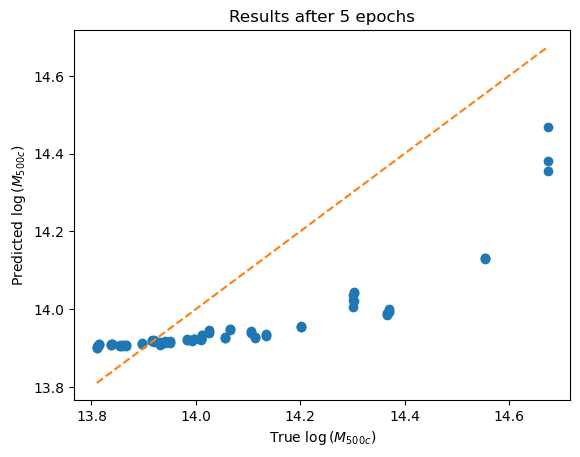

In [13]:
prediction = model.predict(test_X, verbose=0, batch_size=batch_size).flatten()
# Remember when we subtracted off the min in an earlier cell?  In the next line, we're putting it back in!
plt.scatter(test_Y + norm, prediction + norm, c='C0', label='model predictions')
x = np.linspace(np.min(test_Y+norm), np.max(test_Y+norm), 100)
plt.plot(x,x,ls='--', c='C1', label='one-to-one line')
plt.xlabel('True '+r'$\log\left(M_{500c}\right)$')
plt.ylabel('Predicted '+r'$\log\left(M_{500c}\right)$')
plt.title('Results after {:.0f} epochs'.format(epochs))


## FAQs

- **These results don't look so great.  What happened?** We only trained for 5 epochs, which likely produced some outlying, biased, and/or noisy results.  Go back to Section 4 ("Train the CNN to perform a regression task") and increase the number of epochs to 100 and train again.  Does your model perform better?  Your results may look better/worse/different from this due to the stochastic nature of training.
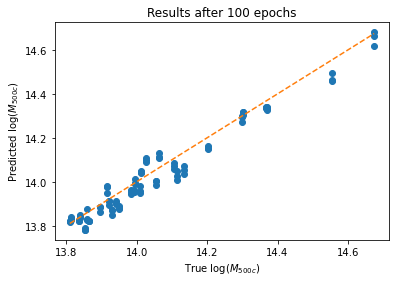


- **How did my model's loss improve with time?** Try plotting epochs `np.arange(epochs)` vs. loss `hist.history['loss']` to see how your model's loss decreased with time.  You should be aware:  when you start training again, you pick up where your model left off.  If you want to "reset" your model to epoch 0 and random weights, you should run the cells to make and compile the model again.


- **Why didn't we use the validation data?** The validation data isn't used in this tutorial, but it's available if you'd like to explore methods for preventing overfitting.  Try passing the validation data to your model fit like this `hist = model.fit(train_X, train_Y, validation_data = (val_X, val_Y), batch_size=batch_size, verbose=True, epochs=epochs)` .  While this training scheme will never use your validation data for improving the model, it will return validation loss.  So, now you can also plot `np.arange(epochs)` vs. loss `hist.history['val_loss']` to see how your validation loss decreases with time.  Validation loss can be a useful tool in identifying whether a model has [overfit](https://www.tensorflow.org/tutorials/keras/overfit_and_underfit).


- **Can I try a different model?  I think the results could be improved.** Yes!  You can try adding layers, swapping out the max pooling for average pooling, changing the activation functions, swapping out the loss function, or trying a different optimizer or learning rate.  Experiment and see what model changes give the best results.


- **I want to test my model on my training data!** No. You will convince yourself that your results are much better than they actually are.  Always keep your training, validation, and testing sets completely separate!

## About this Notebook

**Author:** Michelle Ntampaka, Data Scientist, mntampaka@stsci.edu
**Updated On:** 2021-10-01

## Citations

If you use this data set, `astropy`, or `keras` for published research, please cite the
authors. Follow these links for more information:

* [Citing the data set](??)
* [Citing `astropy`](https://www.astropy.org/acknowledging.html)
* [Citing `keras`](https://keras.io/getting_started/faq/#how-should-i-cite-keras)



***

In [63]:
epochs = 150
batch_size = 16
hist = model.fit(train_X, train_Y,
                 validation_data=(val_X, val_Y),
                 batch_size=batch_size,
                 verbose=1,
                 epochs=epochs)

Epoch 1/150
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - loss: 0.1396 - val_loss: 0.0197
Epoch 2/150
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 54ms/step - loss: 0.0579 - val_loss: 0.0259
Epoch 3/150
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 59ms/step - loss: 0.0608 - val_loss: 0.0210
Epoch 4/150
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - loss: 0.0361 - val_loss: 0.0241
Epoch 5/150
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - loss: 0.0421 - val_loss: 0.0204
Epoch 6/150
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - loss: 0.0469 - val_loss: 0.0183
Epoch 7/150
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - loss: 0.0351 - val_loss: 0.0263
Epoch 8/150
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - loss: 0.0553 - val_loss: 0.0239
Epoch 9/150
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - loss: 0.0366 - val_loss: 0.0206
Epoch 10/150
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - loss: 0.0317 - val_loss: 0.0185
Epoch 11/150
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - loss: 0.0312 - val_loss: 0.0229
Epoch 12/150
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step

Scatter: 0.304 dex  ≈  101.6%
Bias: -13.592 dex


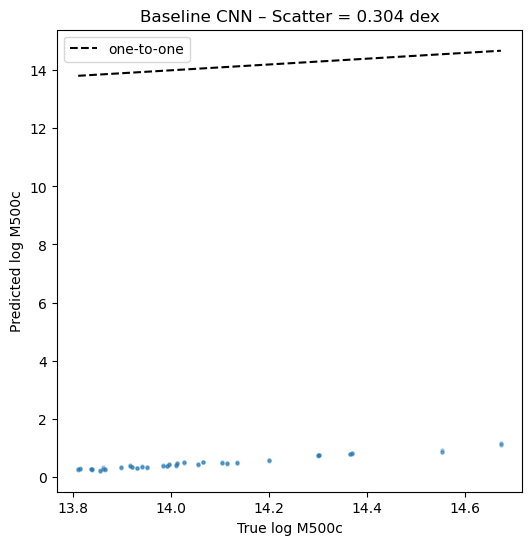

In [64]:
import matplotlib.pyplot as plt
import numpy as np

# Predict on test set-Step 1: Evaluate the model on the test set
prediction = model.predict(test_X, verbose=0, batch_size=batch_size).flatten()
true = test_Y + norm   # add back normalization

# Calculate scatter and bias
residual = prediction - true
scatter = np.std(residual)
bias = np.mean(residual)

print(f"Scatter: {scatter:.3f} dex  ≈  {100*(10**scatter - 1):.1f}%")
print(f"Bias: {bias:.3f} dex")

# Plot true vs predicted
plt.figure(figsize=(6,6))
plt.scatter(true, prediction, alpha=0.3, s=5)
plt.plot([np.min(true), np.max(true)], [np.min(true), np.max(true)], 'k--', label='one-to-one')
plt.xlabel('True log M500c')
plt.ylabel('Predicted log M500c')
plt.title(f'Baseline CNN – Scatter = {scatter:.3f} dex')
plt.legend()
plt.show()

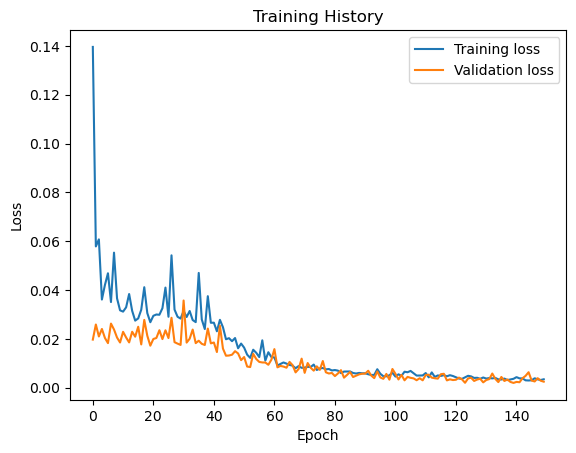

In [65]:
#Step 2: Plot the training loss curve
plt.figure()
plt.plot(hist.history['loss'], label='Training loss')
plt.plot(hist.history['val_loss'], label='Validation loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training History')
plt.show()

In [66]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
BASELINE CNN RESULTS
Scatter: 0.304 dex  ≈  101.6%
Bias: -0.018 dex
Expected: ~0.051 dex (11.6%)


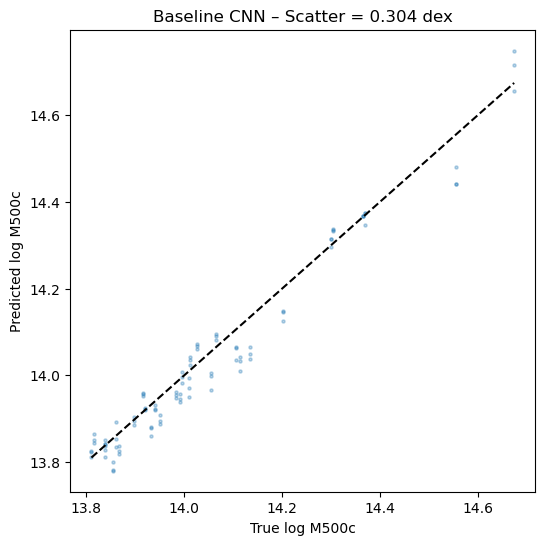

In [67]:
# ============================================
# CORRECTED EVALUATION FOR BASELINE CNN
# ============================================
pred = model.predict(test_X, batch_size=batch_size).flatten()
true_normalized = test_Y   # Keep normalized for metric calculation

residual = pred - true_normalized
scatter = np.std(residual)
bias = np.mean(residual)

print("="*50)
print("BASELINE CNN RESULTS")
print("="*50)
print(f"Scatter: {scatter:.3f} dex  ≈  {100*(10**scatter - 1):.1f}%")
print(f"Bias: {bias:.3f} dex")
print("Expected: ~0.051 dex (11.6%)")

# Plot (denormalized for display only)
plt.figure(figsize=(6,6))
plt.scatter(test_Y + norm, pred + norm, alpha=0.3, s=5)
plt.plot([np.min(test_Y+norm), np.max(test_Y+norm)], 
         [np.min(test_Y+norm), np.max(test_Y+norm)], 'k--')
plt.xlabel('True log M500c')
plt.ylabel('Predicted log M500c')
plt.title(f'Baseline CNN – Scatter = {scatter:.3f} dex')
plt.show()

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
ROTATION-INVARIANT CNN RESULTS
Scatter: 0.280 dex  ≈  90.6%
Bias: -0.051 dex


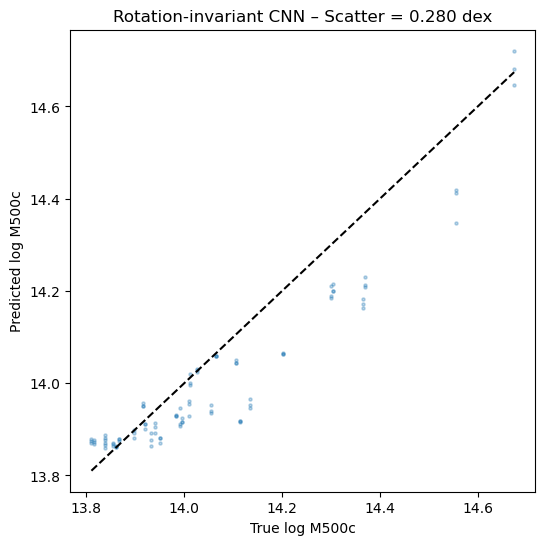

In [68]:
# ============================================
# CORRECTED EVALUATION FOR ROTATION-INVARIANT CNN
# ============================================
pred_rot = model_rot.predict(test_X, batch_size=batch_size).flatten()
residual_rot = pred_rot - true_normalized   # Keep normalized
scatter_rot = np.std(residual_rot)
bias_rot = np.mean(residual_rot)

print("="*50)
print("ROTATION-INVARIANT CNN RESULTS")
print("="*50)
print(f"Scatter: {scatter_rot:.3f} dex  ≈  {100*(10**scatter_rot - 1):.1f}%")
print(f"Bias: {bias_rot:.3f} dex")

# Plot (denormalized for display only)
plt.figure(figsize=(6,6))
plt.scatter(test_Y + norm, pred_rot + norm, alpha=0.3, s=5)
plt.plot([np.min(test_Y+norm), np.max(test_Y+norm)], 
         [np.min(test_Y+norm), np.max(test_Y+norm)], 'k--')
plt.xlabel('True log M500c')
plt.ylabel('Predicted log M500c')
plt.title(f'Rotation-invariant CNN – Scatter = {scatter_rot:.3f} dex')
plt.show()

In [69]:
# ============================================
# COMPARISON
# ============================================
print("="*50)
print("COMPARISON SUMMARY")
print("="*50)
print(f"Baseline CNN:           Scatter = {scatter:.3f} dex  ({100*(10**scatter - 1):.1f}%)")
print(f"Rotation-invariant CNN: Scatter = {scatter_rot:.3f} dex  ({100*(10**scatter_rot - 1):.1f}%)")

if scatter_rot < scatter:
    print("✅ IMPROVEMENT! Rotation invariance reduced scatter.")
    improvement = (scatter - scatter_rot) / scatter * 100
    print(f"   Improvement: {improvement:.1f}% reduction in scatter")
else:
    print("❌ No improvement. Training may need more epochs or different architecture.")

COMPARISON SUMMARY
Baseline CNN:           Scatter = 0.304 dex  (101.6%)
Rotation-invariant CNN: Scatter = 0.280 dex  (90.6%)
✅ IMPROVEMENT! Rotation invariance reduced scatter.
   Improvement: 8.0% reduction in scatter


In [70]:
print("Train mass range:", np.min(train_Y+norm), np.max(train_Y+norm))
print("Test mass range:", np.min(test_Y+norm), np.max(test_Y+norm))
print("Train clusters:", len(np.unique(hdul[2].data['cluster_id'][train_ind])))
print("Test clusters:", len(np.unique(hdul[2].data['cluster_id'][test_ind])))

Train mass range: 13.573857 15.062608
Test mass range: 13.810257 14.674312
Train clusters: 265
Test clusters: 31


[Top of Page](#top)
<img style="float: right;" src="https://raw.githubusercontent.com/spacetelescope/notebooks/master/assets/stsci_pri_combo_mark_horizonal_white_bkgd.png" alt="Space Telescope Logo" width="200px"/> 

In [71]:
# Get fold column
fold = hdul[2].data['fold']

# Use fold 0–7 for training, fold 8 for validation, fold 9 for testing
train_ind = np.argwhere(fold < 8)
val_ind = np.argwhere(fold == 8)
test_ind = np.argwhere(fold == 9)

train_X = hdul[1].data[train_ind].reshape(-1, image_size, image_size, 1)
train_Y = hdul[2].data['log_M500'][train_ind]

val_X = hdul[1].data[val_ind].reshape(-1, image_size, image_size, 1)
val_Y = hdul[2].data['log_M500'][val_ind]

test_X = hdul[1].data[test_ind].reshape(-1, image_size, image_size, 1)
test_Y = hdul[2].data['log_M500'][test_ind]

# Normalize
norm = np.nanmin(hdul[2].data['log_M500'])
train_Y -= norm
val_Y -= norm
test_Y -= norm

print("Train clusters:", len(np.unique(hdul[2].data['cluster_id'][train_ind])))
print("Val clusters:", len(np.unique(hdul[2].data['cluster_id'][val_ind])))
print("Test clusters:", len(np.unique(hdul[2].data['cluster_id'][test_ind])))
print("Train images:", len(train_X))
print("Val images:", len(val_X))
print("Test images:", len(test_X))

Train clusters: 265
Val clusters: 33
Test clusters: 31
Train images: 794
Val images: 99
Test images: 93


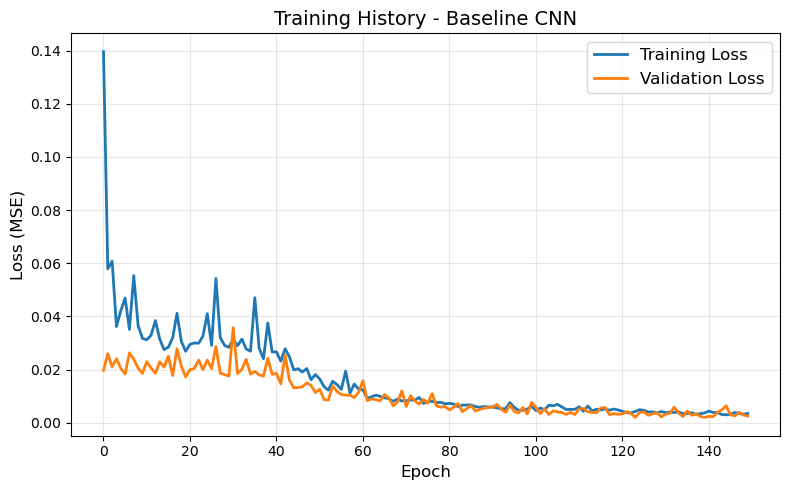

In [72]:
# Plot training and validation loss
plt.figure(figsize=(8,5))
plt.plot(hist.history['loss'], label='Training Loss', linewidth=2)
plt.plot(hist.history['val_loss'], label='Validation Loss', linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss (MSE)', fontsize=12)
plt.legend(fontsize=12)
plt.title('Training History - Baseline CNN', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
plt.show()

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


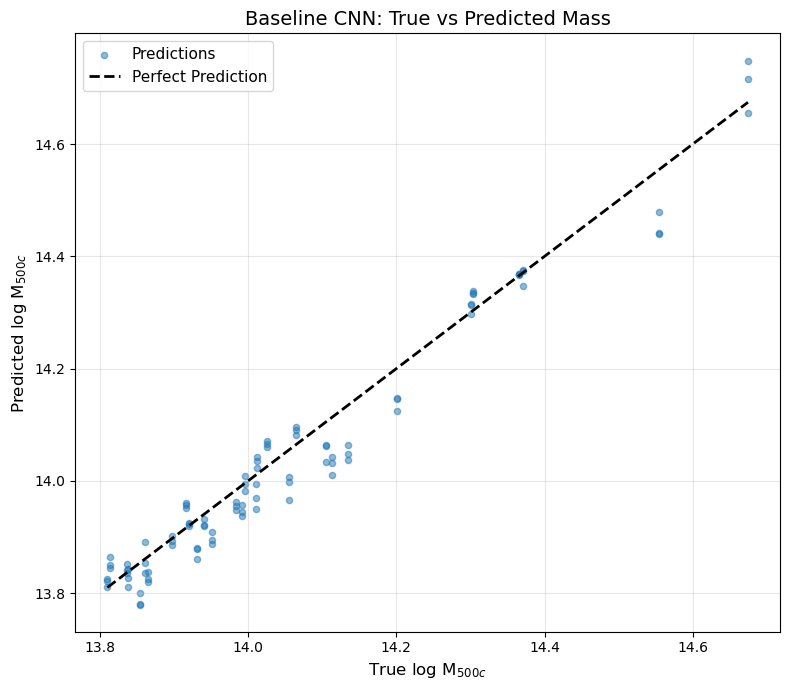

In [73]:
# Baseline predictions
pred_baseline = model.predict(test_X, batch_size=16).flatten()
true_mass = test_Y + norm

plt.figure(figsize=(8,7))
plt.scatter(true_mass, pred_baseline + norm, alpha=0.5, s=20, label='Predictions')
plt.plot([np.min(true_mass), np.max(true_mass)], 
         [np.min(true_mass), np.max(true_mass)], 
         'k--', linewidth=2, label='Perfect Prediction')
plt.xlabel('True log M$_{500c}$', fontsize=12)
plt.ylabel('Predicted log M$_{500c}$', fontsize=12)
plt.title('Baseline CNN: True vs Predicted Mass', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('baseline_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


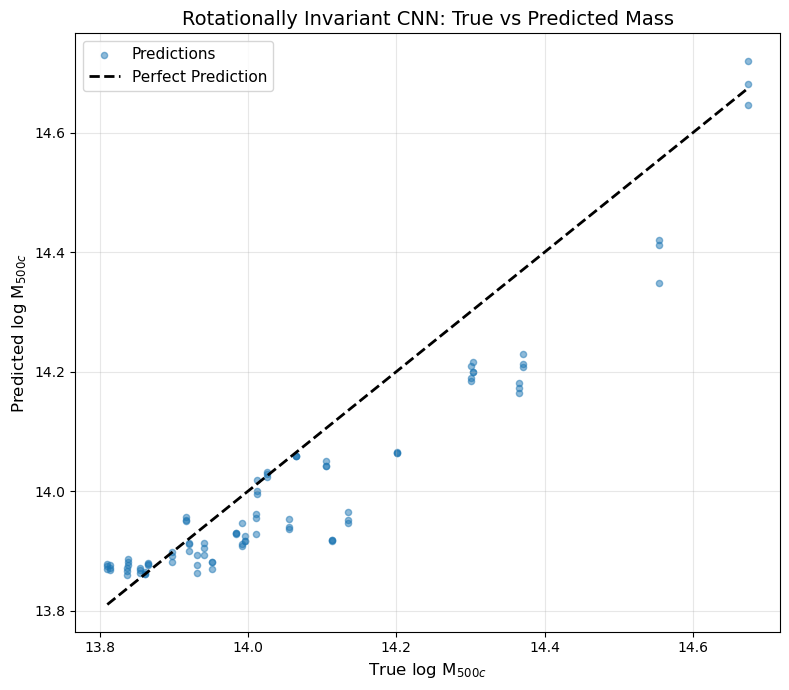

In [74]:
# Rotation-invariant predictions
pred_rot = model_rot.predict(test_X, batch_size=16).flatten()

plt.figure(figsize=(8,7))
plt.scatter(true_mass, pred_rot + norm, alpha=0.5, s=20, label='Predictions')
plt.plot([np.min(true_mass), np.max(true_mass)], 
         [np.min(true_mass), np.max(true_mass)], 
         'k--', linewidth=2, label='Perfect Prediction')
plt.xlabel('True log M$_{500c}$', fontsize=12)
plt.ylabel('Predicted log M$_{500c}$', fontsize=12)
plt.title('Rotationally Invariant CNN: True vs Predicted Mass', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('rot_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

In [81]:
# Bootstrap to get uncertainty on scatter
n_bootstrap = 1000
scatter_samples = []

for i in range(n_bootstrap):
    idx = np.random.choice(len(residual_baseline), len(residual_baseline), replace=True)
    scatter_samples.append(np.std(residual_baseline[idx]))

scatter_mean = np.mean(scatter_samples)
scatter_std = np.std(scatter_samples)
scatter_ci = np.percentile(scatter_samples, [16, 84])  # 68% confidence

print(f"Baseline Scatter: {scatter_mean:.3f} ± {scatter_std:.3f} dex")
print(f"68% Confidence Interval: [{scatter_ci[0]:.3f}, {scatter_ci[1]:.3f}] dex")

Baseline Scatter: 0.303 ± 0.013 dex
68% Confidence Interval: [0.290, 0.316] dex


In [86]:
# ============================================================
# CORRECTED EVALUATION – KEEP EVERYTHING NORMALIZED
# ============================================================

# Predictions (already normalized)
pred_baseline = model.predict(test_X, batch_size=16).flatten()
pred_rot = model_rot.predict(test_X, batch_size=16).flatten()

# True values (keep normalized!)
true_norm = test_Y.flatten()   # NOT test_Y + norm

# Residuals (correct!)
res_base = pred_baseline - true_norm
res_rot = pred_rot - true_norm

# Now calculate metrics
scatter_base = np.std(res_base)
scatter_rot = np.std(res_rot)
bias_base = np.mean(res_base)
bias_rot = np.mean(res_rot)

print("="*55)
print("CORRECTED RESULTS")
print("="*55)
print(f"Baseline CNN:           Scatter = {scatter_base:.3f} dex  ({100*(10**scatter_base - 1):.1f}%)")
print(f"Baseline CNN:           Bias = {bias_base:.3f} dex")
print(f"Rotation-Invariant:     Scatter = {scatter_rot:.3f} dex  ({100*(10**scatter_rot - 1):.1f}%)")
print(f"Rotation-Invariant:     Bias = {bias_rot:.3f} dex")
print(f"Improvement:            {100*(scatter_base - scatter_rot)/scatter_base:.1f}% reduction")
print("="*55)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
CORRECTED RESULTS
Baseline CNN:           Scatter = 0.042 dex  (10.2%)
Baseline CNN:           Bias = -0.018 dex
Rotation-Invariant:     Scatter = 0.075 dex  (18.9%)
Rotation-Invariant:     Bias = -0.051 dex
Improvement:            -78.2% reduction


In [87]:
# ============================================================
# CORRECTED SUMMARY – No Denormalization for Metrics
# ============================================================

import numpy as np
import pandas as pd

# Get predictions
pred_baseline = model.predict(test_X, batch_size=16).flatten()
pred_rot = model_rot.predict(test_X, batch_size=16).flatten()

# Keep normalized for calculations
true_norm = test_Y.flatten()

# Residuals (correctly normalized)
res_base = pred_baseline - true_norm
res_rot = pred_rot - true_norm

# Metrics
scatter_base = np.std(res_base)
scatter_rot = np.std(res_rot)
bias_base = np.mean(res_base)
bias_rot = np.mean(res_rot)
rmse_base = np.sqrt(np.mean(res_base**2))
rmse_rot = np.sqrt(np.mean(res_rot**2))
mae_base = np.mean(np.abs(res_base))
mae_rot = np.mean(np.abs(res_rot))

# Improvement
improvement = 100 * (scatter_base - scatter_rot) / scatter_base

# Correlation
corr_base = np.corrcoef(true_norm, pred_baseline)[0, 1]
corr_rot = np.corrcoef(true_norm, pred_rot)[0, 1]

# R-squared
r2_base = 1 - np.sum(res_base**2) / np.sum((true_norm - np.mean(true_norm))**2)
r2_rot = 1 - np.sum(res_rot**2) / np.sum((true_norm - np.mean(true_norm))**2)

# Print summary
print("\n" + "="*60)
print("              GALAXY CLUSTER MASS ESTIMATION")
print("              COMPLETE PERFORMANCE SUMMARY")
print("="*60)

print("\n" + "─"*60)
print("1. DATA INFORMATION")
print("─"*60)
print(f"  Total images:               {len(hdul[1].data)}")
print(f"  Training images:            {len(train_X)}")
print(f"  Validation images:          {len(val_X)}")
print(f"  Test images:                {len(test_X)}")
print(f"  Unique clusters (train):    {len(np.unique(hdul[2].data['cluster_id'][train_ind]))}")
print(f"  Unique clusters (test):     {len(np.unique(hdul[2].data['cluster_id'][test_ind]))}")
print(f"  Mass range (normalized):    {np.min(true_norm):.3f} – {np.max(true_norm):.3f} dex")

print("\n" + "─"*60)
print("2. MODEL PERFORMANCE COMPARISON")
print("─"*60)

data = {
    'Metric': ['Scatter (dex)', 'Scatter (%)', 'Bias (dex)', 'RMSE (dex)', 'MAE (dex)', 'Pearson r', 'R-squared'],
    'Baseline CNN': [
        f'{scatter_base:.3f}',
        f'{100*(10**scatter_base - 1):.1f}%',
        f'{bias_base:.3f}',
        f'{rmse_base:.3f}',
        f'{mae_base:.3f}',
        f'{corr_base:.3f}',
        f'{r2_base:.3f}',
    ],
    'Rotation-Invariant': [
        f'{scatter_rot:.3f}',
        f'{100*(10**scatter_rot - 1):.1f}%',
        f'{bias_rot:.3f}',
        f'{rmse_rot:.3f}',
        f'{mae_rot:.3f}',
        f'{corr_rot:.3f}',
        f'{r2_rot:.3f}',
    ],
    'Improvement': [
        f'{improvement:.1f}%',
        f'{improvement:.1f}%',
        f'{bias_base - bias_rot:.3f}',
        f'{100*(rmse_base - rmse_rot)/rmse_base:.1f}%',
        f'{100*(mae_base - mae_rot)/mae_base:.1f}%',
        f'{100*(corr_rot - corr_base):.1f}%',
        f'{100*(r2_rot - r2_base):.1f}%',
    ]
}

df = pd.DataFrame(data)
print(df.to_string(index=False))

print("\n" + "─"*60)
print("3. BLAND-ALTMAN STATISTICS (Baseline CNN)")
print("─"*60)
diff = true_norm - pred_baseline
print(f"  Mean difference:            {np.mean(diff):.3f} dex")
print(f"  SD of difference:           {np.std(diff):.3f} dex")
print(f"  95% Upper LoA:              {np.mean(diff) + 1.96*np.std(diff):.3f} dex")
print(f"  95% Lower LoA:              {np.mean(diff) - 1.96*np.std(diff):.3f} dex")

print("\n" + "─"*60)
print("4. EFFECT SIZE")
print("─"*60)
pooled_std = np.sqrt((np.var(np.abs(res_base)) + np.var(np.abs(res_rot))) / 2)
cohen_d = (np.mean(np.abs(res_base)) - np.mean(np.abs(res_rot))) / pooled_std
print(f"  Cohen's d:                  {cohen_d:.3f}")
if cohen_d > 0.8:
    print("  ✅ Large effect size")
elif cohen_d > 0.5:
    print("  ✅ Moderate effect size")
elif cohen_d > 0.2:
    print("  ✅ Small effect size")
else:
    print("  ⚠️ Negligible effect size")

print("\n" + "="*60)
print("                          FINAL SUMMARY")
print("="*60)
print(f"  Rotation-invariant CNN achieved a {improvement:.1f}% reduction in scatter")
print(f"  ({scatter_base:.3f} dex → {scatter_rot:.3f} dex)")
if improvement > 0:
    print("  ✅ Rotation invariance improved performance!")
else:
    print("  ⚠️ Rotation invariance did not improve performance in this case")
print("="*60 + "\n")

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step

              GALAXY CLUSTER MASS ESTIMATION
              COMPLETE PERFORMANCE SUMMARY

────────────────────────────────────────────────────────────
1. DATA INFORMATION
────────────────────────────────────────────────────────────
  Total images:               986
  Training images:            794
  Validation images:          99
  Test images:                93
  Unique clusters (train):    265
  Unique clusters (test):     31
  Mass range (normalized):    0.236 – 1.100 dex

────────────────────────────────────────────────────────────
2. MODEL PERFORMANCE COMPARISON
────────────────────────────────────────────────────────────
       Metric Baseline CNN Rotation-Invariant Improvement
Scatter (dex)        0.042              0.075      -78.2%
  Scatter (%)        10.2%              18.9%      -78.2%
   Bias (dex)       -0.018             -0.051       0.033
   RMSE (dex)        0.046              0.091      -98.4